## Rumusan Masalah
- Bagaimana proses preprocessing teks memengaruhi kualitas representasi komentar TikTok?
- Metode clustering mana yang memberikan kualitas pemisahan cluster lebih baik, K-Means atau AHC?
- Topik komentar apa saja yang dominan berdasarkan hasil pengelompokan cluster?

## 1. Import Library

In [1]:
# Import semua library yang dibutuhkan
import pandas as pd
import re
import string
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Preprocessing libraries
from indoNLP.preprocessing import remove_stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Sklearn libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Scipy libraries
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# WordCloud library
from wordcloud import WordCloud

## 2. Memuat Dataset dan Inisialisasi Awal

In [2]:

df = pd.read_csv('Tiktok.csv')

# Inisialisasi Sastrawi Stemmer untuk proses stemming
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Daftar stopword custom yang ingin dihapus selain stopword default
custom_stopwords = ['kakak', 'ya', 'nya']

## 3. Cleaning Teks

In [3]:

# Load kamus gaul dari file CSV untuk normalisasi kata
slang = pd.read_csv('slang_indo.csv', header=None, names=['slang', 'formal'])
kamus_gaul = dict(zip(slang['slang'], slang['formal']))

# Fungsi Cleaning
def cleaning(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # Hapus URL
    text = re.sub(r'@\w+', '', text)  # Hapus mention (@username)
    text = re.sub(r'#\w+', '', text)  # Hapus hashtag
    text = re.sub(r'[^\w\s]', '', text)  # Hapus tanda baca dan karakter khusus
    text = re.sub(r'[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF\U0001F700-\U0001F77F\U0001F780-\U0001F7FF\U0001F800-\U0001F8FF\U0001F900-\U0001F9FF\U0001FA00-\U0001FA6F\U0001FA70-\U0001FAFF\U00002702-\U000027B0\U000024C2-\U0001F251]', '', text)  # Hapus emoji
    text = re.sub(r'\d+', '', text)  # Hapus angka
    text = re.sub(r'(.)\1{2,}', r'\1', text)  # Hapus karakter berulang (contoh: 'yaaaaaa' menjadi 'ya')
    text = re.sub(r'\s+', ' ', text).strip()  # Hapus spasi berlebih dan trim
    return text

df['cleaned'] = df['comment_text'].fillna('').apply(cleaning)

df[['comment_text', 'cleaned']].head()


,comment_text,cleaned
0,ini sama kah sama yang di Shopee?\r\nsoalnya b...,ini sama kah sama yang di Shopee soalnya brand...
1,bb 60 tb 170 uk apa kak,bb tb uk apa kak
2,tb 185 bb100?,tb bb
3,"bb 56, tb 175+ apa",bb tb apa
4,finally ada brand yg keluarin katalog clean lo...,finally ada brand yg keluarin katalog clean lo...


## 4. Case Folding

In [4]:
# Fungsi Case Folding
def case_folding(text):
    return text.lower()

df['casefol'] = df['cleaned'].apply(case_folding)

df[['cleaned', 'casefol']].head()

,cleaned,casefol
0,ini sama kah sama yang di Shopee soalnya brand...,ini sama kah sama yang di shopee soalnya brand...
1,bb tb uk apa kak,bb tb uk apa kak
2,tb bb,tb bb
3,bb tb apa,bb tb apa
4,finally ada brand yg keluarin katalog clean lo...,finally ada brand yg keluarin katalog clean lo...


## 5. Normalisasi Kata Gaul

In [5]:
# Fungsi Normalisasi
def normalisasi(text):
    words = text.split()
    return ' '.join([kamus_gaul.get(word.lower(), word) for word in words])

df['normalized'] = df['casefol'].apply(normalisasi)

df[['casefol', 'normalized']].head()

,casefol,normalized
0,ini sama kah sama yang di shopee soalnya brand...,ini sama kah sama yang di shopee soalnya brand...
1,bb tb uk apa kak,berat badan tinggi badan ukuran apa kakak
2,tb bb,tinggi badan berat badan
3,bb tb apa,berat badan tinggi badan apa
4,finally ada brand yg keluarin katalog clean lo...,akhirnya ada brand yang keluarin katalog clean...


## 6. Tokenisasi

In [6]:
# Funsi Tokenisasi
def tokenizing(text):
    return text.split()

df['tokens'] = df['normalized'].apply(tokenizing)

df[['normalized', 'tokens']].head()

,normalized,tokens
0,ini sama kah sama yang di shopee soalnya brand...,"[ini, sama, kah, sama, yang, di, shopee, soaln..."
1,berat badan tinggi badan ukuran apa kakak,"[berat, badan, tinggi, badan, ukuran, apa, kakak]"
2,tinggi badan berat badan,"[tinggi, badan, berat, badan]"
3,berat badan tinggi badan apa,"[berat, badan, tinggi, badan, apa]"
4,akhirnya ada brand yang keluarin katalog clean...,"[akhirnya, ada, brand, yang, keluarin, katalog..."


## 7. Stopword Removal

In [7]:
# Fungsi Stopword Removal
def stopword_removal(tokens):
    text = ' '.join(tokens)
    text_cleaned = remove_stopwords(text)
    tokens_cleaned = text_cleaned.split()
    
    # Tambahkan filter untuk custom stopwords
    tokens_cleaned = [word for word in tokens_cleaned if word not in custom_stopwords]
    
    return tokens_cleaned

df['no_stopword'] = df['tokens'].apply(stopword_removal)

df[['tokens', 'no_stopword']].head()

,tokens,no_stopword
0,"[ini, sama, kah, sama, yang, di, shopee, soaln...","[kah, shopee, brand, namanya, shoope, murah]"
1,"[berat, badan, tinggi, badan, ukuran, apa, kakak]","[berat, badan, tinggi, badan, ukuran]"
2,"[tinggi, badan, berat, badan]","[tinggi, badan, berat, badan]"
3,"[berat, badan, tinggi, badan, apa]","[berat, badan, tinggi, badan]"
4,"[akhirnya, ada, brand, yang, keluarin, katalog...","[brand, keluarin, katalog, clean, look, capai,..."


## 8. Stemming

In [8]:
# Fungsi Stemming
def stemming(tokens):
    return [stemmer.stem(word) for word in tokens]

df['stemmed'] = df['no_stopword'].apply(stemming)
df = df[df['stemmed'].apply(lambda x: len(x) > 0)]

df[['no_stopword', 'stemmed']].head()

,no_stopword,stemmed
0,"[kah, shopee, brand, namanya, shoope, murah]","[kah, shopee, brand, nama, shoope, murah]"
1,"[berat, badan, tinggi, badan, ukuran]","[berat, badan, tinggi, badan, ukur]"
2,"[tinggi, badan, berat, badan]","[tinggi, badan, berat, badan]"
3,"[berat, badan, tinggi, badan]","[berat, badan, tinggi, badan]"
4,"[brand, keluarin, katalog, clean, look, capai,...","[brand, keluarin, katalog, clean, look, capai,..."


## 9. Ekstraksi Fitur TF-IDF

In [9]:
df['text_for_tfidf'] = df['stemmed'].apply(lambda x: ' '.join(x))

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['text_for_tfidf'])

## 10. Menentukan Jumlah Cluster (Elbow Method)

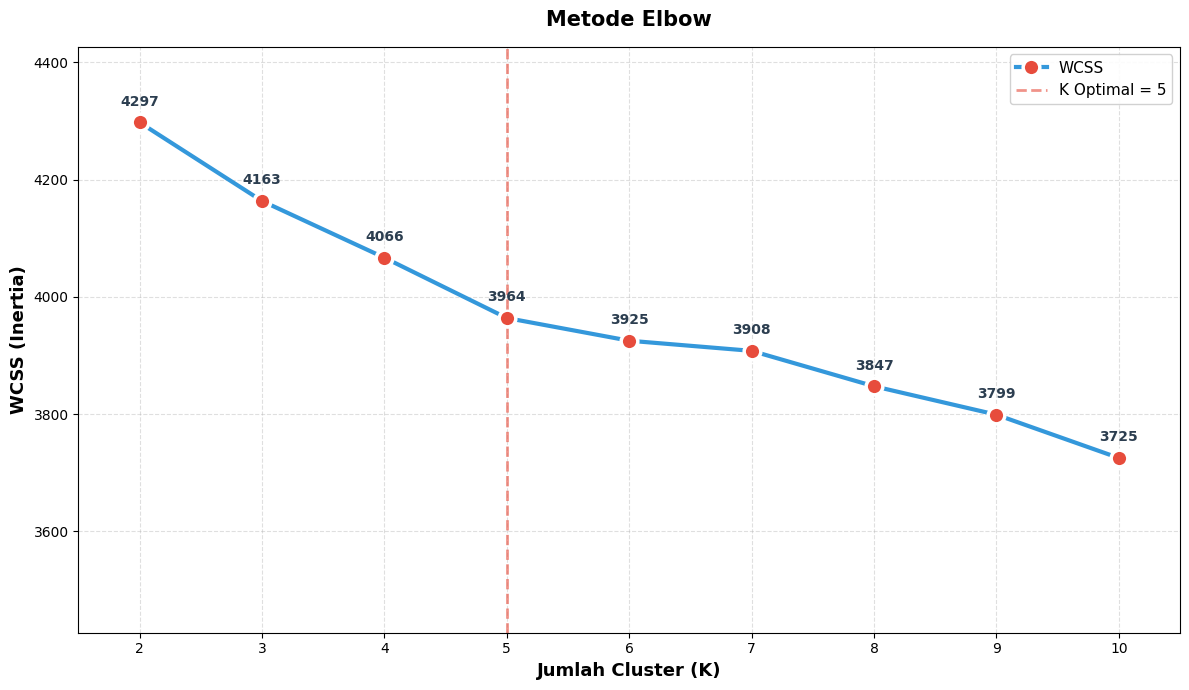

In [25]:
K_range = range(2, 11)

# Hitung WCSS (Within-Cluster Sum of Squares) untuk setiap K
wcss = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(tfidf_matrix).inertia_ for k in K_range]

fig, ax = plt.subplots(figsize=(12, 7))

# Plot garis WCSS dengan warna solid yang jelas
ax.plot(K_range, wcss, color='#3498db', linewidth=3, marker='o', 
        markersize=12, markerfacecolor='#e74c3c', markeredgecolor='white', 
        markeredgewidth=2.5, label='WCSS')

# Label nilai WCSS pada setiap titik
for k, w in zip(K_range, wcss):
    ax.annotate(f'{int(w)}', xy=(k, w), xytext=(0, 12), 
                textcoords='offset points', ha='center', fontsize=10, 
                fontweight='bold', color='#2c3e50')

# Garis vertikal merah di K optimal (5)
ax.axvline(x=5, color='#e74c3c', linestyle='--', linewidth=2, alpha=0.6, label='K Optimal = 5')

ax.set_xlabel('Jumlah Cluster (K)', fontsize=13, fontweight='bold')
ax.set_ylabel('WCSS (Inertia)', fontsize=13, fontweight='bold')
ax.set_title('Metode Elbow', fontsize=15, fontweight='bold', pad=15)
ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.8)
ax.set_xticks(K_range)
ax.set_xlim(K_range[0] - 0.5, K_range[-1] + 0.5)
ax.set_ylim(min(wcss) * 0.92, max(wcss) * 1.03)
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.show()

## 11. Training Model K-Means

In [11]:
# Tentukan jumlah cluster optimal berdasarkan metode elbow
optimal_k = 5

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = cluster_labels = kmeans_final.fit_predict(tfidf_matrix)

## 12. Distribusi Anggota Cluster K-Means

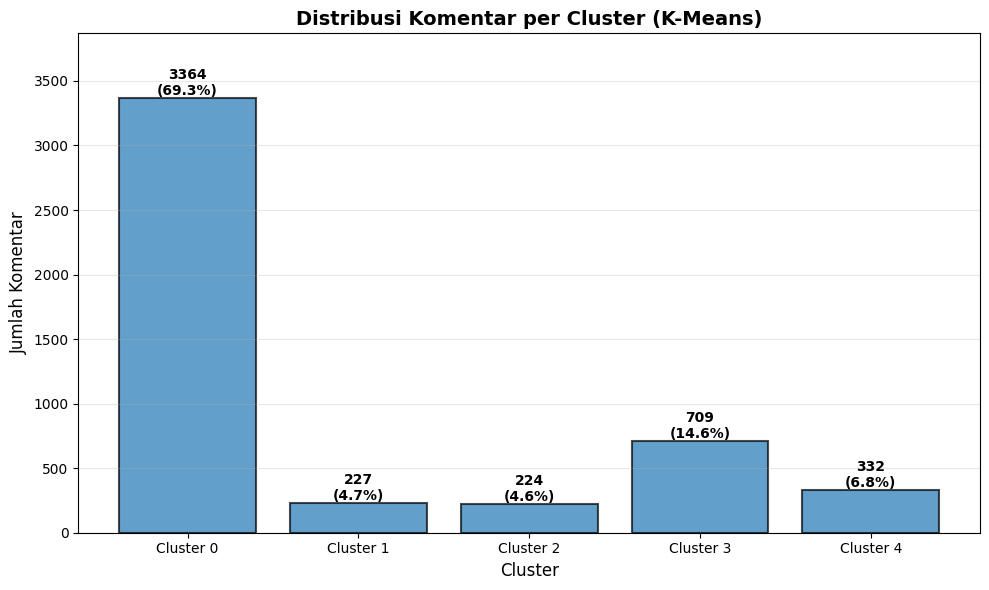

In [29]:
# Generate warna untuk setiap cluster
if 'colors' not in globals():
    colors = plt.cm.tab10(np.linspace(0, 1, optimal_k))

cluster_counts = df['cluster'].value_counts().sort_index()

# Hitung persentase data di setiap cluster
cluster_percentages = (cluster_counts / len(df) * 100)

# Buat bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(range(optimal_k), cluster_counts.values, color=colors, edgecolor='black', linewidth=1.5, alpha=0.7)
for i, (count, pct) in enumerate(zip(cluster_counts.values, cluster_percentages.values)):
    plt.text(i, count, f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Jumlah Komentar', fontsize=12)
plt.title('Distribusi Komentar per Cluster (K-Means)', fontsize=14, fontweight='bold')
plt.xticks(range(optimal_k), [f'Cluster {i}' for i in range(optimal_k)])
plt.ylim(0, max(cluster_counts.values) * 1.15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Word Cloud Cluster K-Means

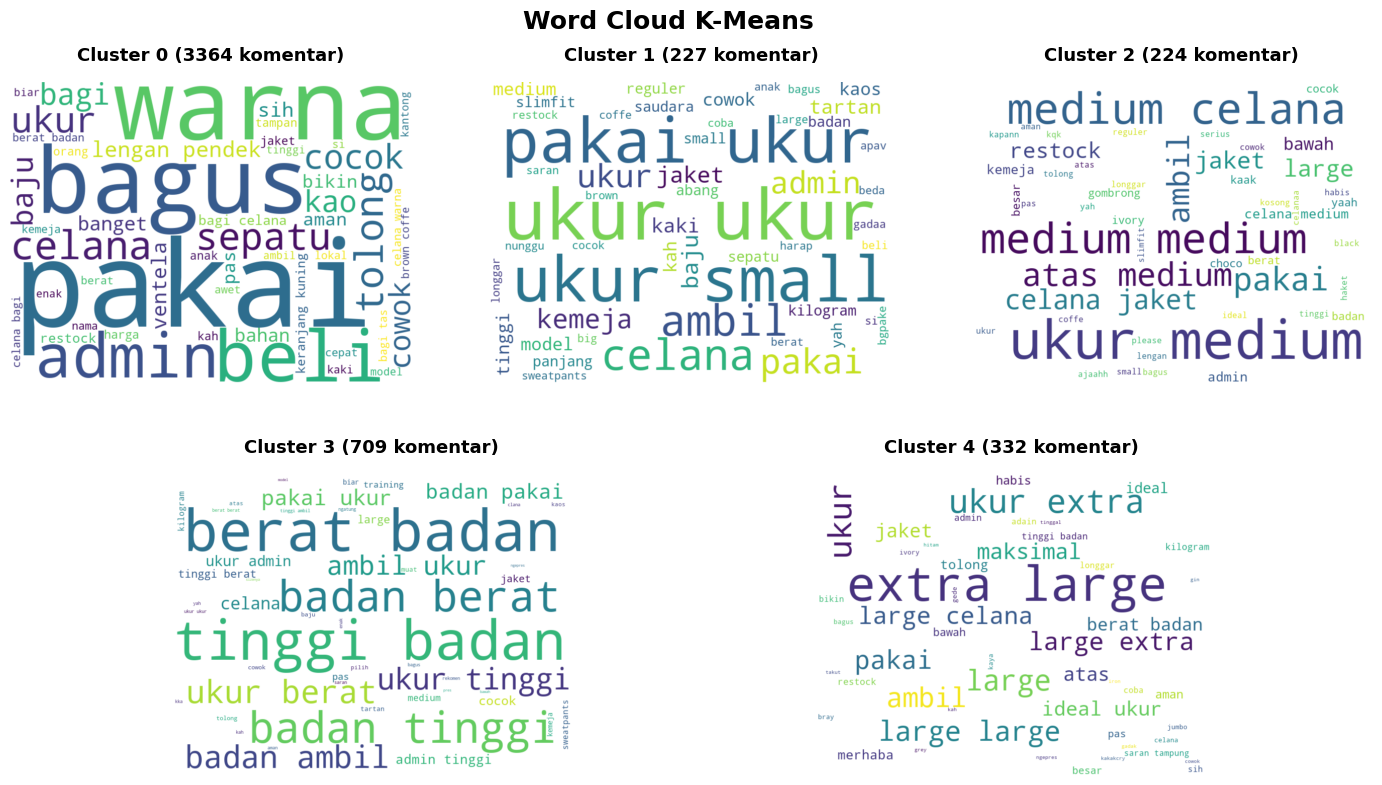

In [27]:
fig = plt.figure(figsize=(18, 9))

# Memakai Grid 2x9 
gs = gridspec.GridSpec(2, 9, figure=fig, hspace=0.3, wspace=0.4)

# Baris pertama: 3 cluster (kolom 0-2, 3-5, 6-8)
positions_row1 = [(0, slice(0, 3)), (0, slice(3, 6)), (0, slice(6, 9))]
# Baris kedua: 2 cluster di tengah (kolom 1.5-4.5 dan 4.5-7.5)
positions_row2 = [(1, slice(1, 4)), (1, slice(5, 8))]

all_positions = positions_row1 + positions_row2

for i in range(optimal_k):
    row, col = all_positions[i]
    ax = fig.add_subplot(gs[row, col])
    
    wc = WordCloud(width=800, height=600, background_color='white', max_words=50, colormap='viridis').generate(' '.join(df[df['cluster'] == i]['text_for_tfidf'].astype(str)))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off') 
    
    ax.set_title(f'Cluster {i} ({cluster_counts.iloc[i]} komentar)', 
                fontsize=13, fontweight='bold', pad=15)

plt.suptitle('Word Cloud K-Means', fontsize=18, fontweight='bold', y=0.96)
plt.show()

## 14. Dendrogram AHC

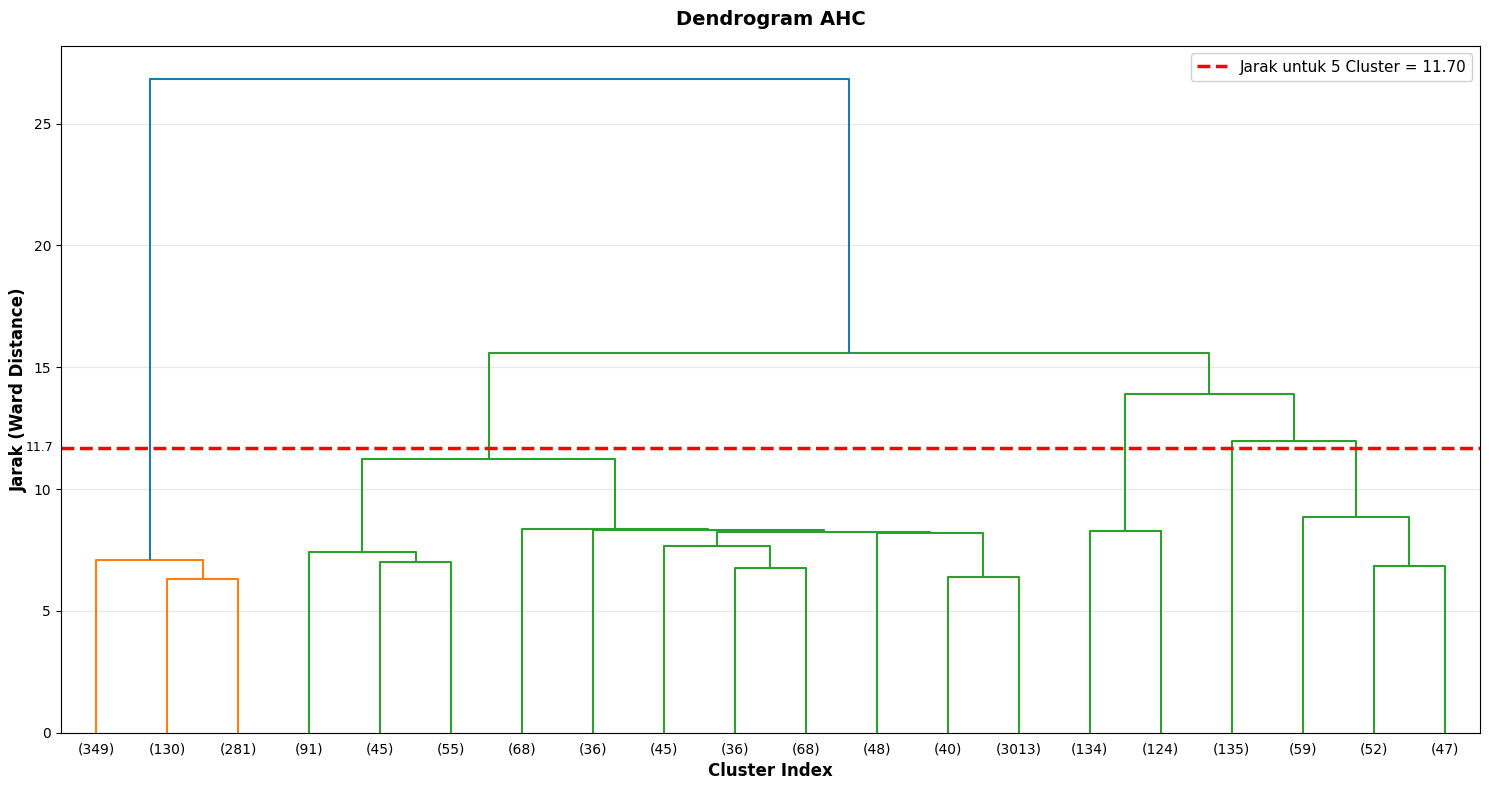

In [35]:
tfidf_array = tfidf_matrix.toarray()

# Buat linkage matrix menggunakan metode Ward
linkage_matrix = linkage(tfidf_array, method='ward')

# Tentukan threshold jarak 
threshold = 11.7

plt.figure(figsize=(15, 8))
dend = dendrogram(linkage_matrix, truncate_mode='lastp', p=20, show_leaf_counts=True, leaf_font_size=10)

# Tambahkan garis horizontal untuk menunjukkan pemotongan
plt.axhline(y=threshold, color='red', linestyle='--', linewidth=2.5, 
            label=f'Jarak untuk {optimal_k} Cluster = {threshold:.2f}')

# Tambahkan label angka di axis untuk threshold
plt.text(-1, threshold, f'{threshold:.1f}', va='center', ha='right', 
         fontsize=9, color='black')

plt.xlabel('Cluster Index', fontsize=12, fontweight='bold')
plt.ylabel('Jarak (Ward Distance)', fontsize=12, fontweight='bold')
plt.title('Dendrogram AHC', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='upper right', fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 15. Pelabelan Cluster AHC

In [15]:
# Clustering menggunakan threshold jarak
cluster_labels_ahc = fcluster(linkage_matrix, t=threshold, criterion='distance') - 1  # -1 untuk mulai dari 0

df['cluster_ahc'] = cluster_labels_ahc

## 16. Distribusi Anggota Cluster AHC

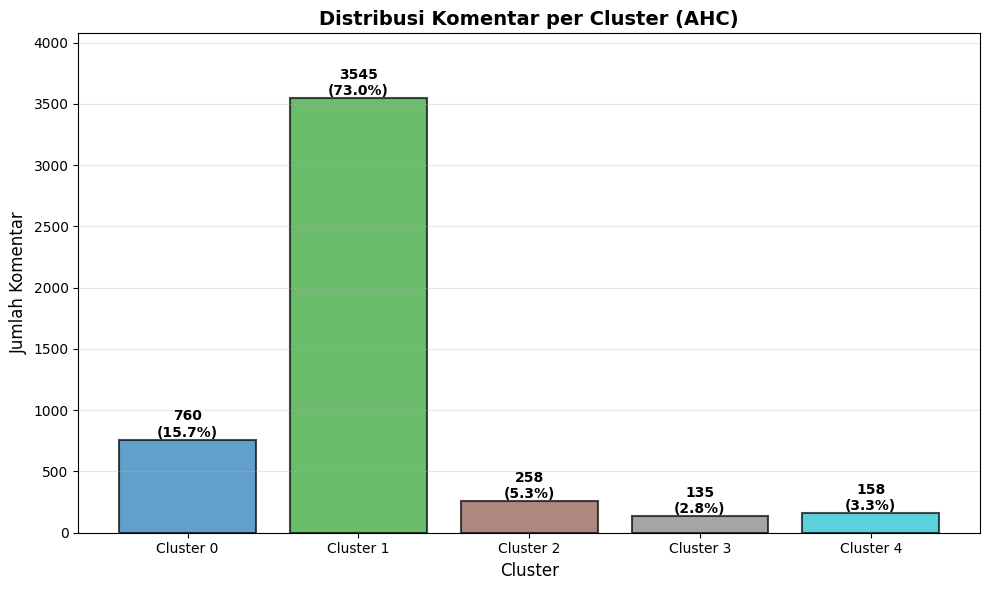

In [30]:
cluster_counts_ahc = df['cluster_ahc'].value_counts().sort_index()

# Hitung persentase data di setiap cluster AHC
cluster_percentages_ahc = (cluster_counts_ahc / len(df) * 100)

plt.figure(figsize=(10, 6))

# Generate warna untuk setiap cluster
colors_ahc = plt.cm.tab10(np.linspace(0, 1, 5))
bars_ahc = plt.bar(range(5), cluster_counts_ahc.values, color=colors_ahc, edgecolor='black', linewidth=1.5, alpha=0.7)
for i, (count, pct) in enumerate(zip(cluster_counts_ahc.values, cluster_percentages_ahc.values)):
    plt.text(i, count, f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Jumlah Komentar', fontsize=12)
plt.title('Distribusi Komentar per Cluster (AHC)', fontsize=14, fontweight='bold')
plt.xticks(range(5), [f'Cluster {i}' for i in range(5)])
plt.ylim(0, max(cluster_counts_ahc.values) * 1.15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 17. Word Cloud Cluster AHC

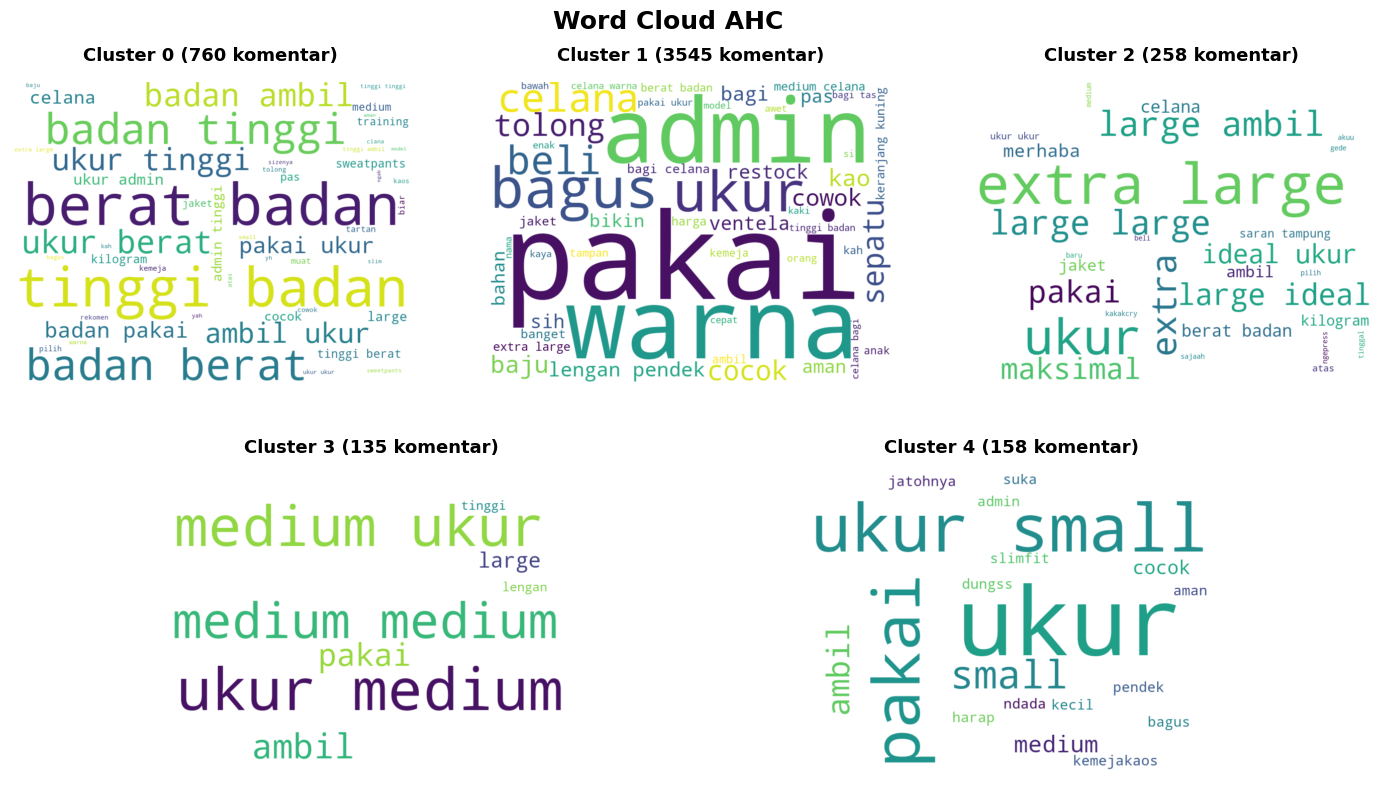

In [28]:
fig_ahc = plt.figure(figsize=(18, 9) )

# Memakai Grid 2x9 
gs_ahc = gridspec.GridSpec(2, 9, figure=fig_ahc, hspace=0.3, wspace=0.4)

# Baris pertama: 3 cluster (kolom 0-2, 3-5, 6-8)
positions_row1_ahc = [(0, slice(0, 3)), (0, slice(3, 6)), (0, slice(6, 9))]
# Baris kedua: 2 cluster di tengah (kolom 1.5-4.5 dan 4.5-7.5)
positions_row2_ahc = [(1, slice(1, 4)), (1, slice(5, 8))]

all_positions_ahc = positions_row1_ahc + positions_row2_ahc

for i in range(5):
    # Ambil posisi untuk cluster ke-i
    row, col = all_positions_ahc[i]
    ax = fig_ahc.add_subplot(gs_ahc[row, col])
    
    wc = WordCloud(width=800, height=600, background_color='white', max_words=50, colormap='viridis').generate(' '.join(df[df['cluster_ahc'] == i]['text_for_tfidf'].astype(str)))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Cluster {i} ({cluster_counts_ahc.iloc[i]} komentar)', fontsize=13, fontweight='bold', pad=15)

plt.suptitle('Word Cloud AHC', fontsize=18, fontweight='bold', y=0.96)
plt.show()

## 18. Evaluasi Model Clustering

- Silhouette Score
- Davies-Bouldin Index

In [18]:
# Hitung Silhouette Score untuk K-Means
silhouette_kmeans = silhouette_score(tfidf_matrix, df['cluster'], metric='cosine')

# Hitung Silhouette Score untuk AHC
silhouette_ahc = silhouette_score(tfidf_matrix, df['cluster_ahc'], metric='cosine')

print(f"Silhouette Score K-Means: {silhouette_kmeans}")
print(f"Silhouette Score AHC: {silhouette_ahc}")

Silhouette Score K-Means: 0.14166226469689916
Silhouette Score AHC: 0.11290184748361312


In [19]:
# Hitung Davies-Bouldin Index untuk K-Means
dbi_kmeans = davies_bouldin_score(tfidf_array, df['cluster'])

# Hitung Davies-Bouldin Index untuk AHC
dbi_ahc = davies_bouldin_score(tfidf_array, df['cluster_ahc'])

print(f"Davies-Bouldin Index K-Means: {dbi_kmeans}")
print(f"Davies-Bouldin Index AHC: {dbi_ahc}")

Davies-Bouldin Index K-Means: 2.4087991922499006
Davies-Bouldin Index AHC: 2.1722915454872584


In [20]:
df.to_csv('Tiktok_cluster.csv', index=False)

## Kesimpulan dan Insight Akhir

- Pipeline preprocessing (cleaning, normalisasi, tokenisasi, stopword removal, dan stemming) berhasil menyiapkan data komentar menjadi fitur yang siap di-cluster.
- Perbandingan K-Means dan AHC dilakukan secara kuantitatif melalui Silhouette Score dan Davies-Bouldin Index, serta secara kualitatif melalui distribusi cluster dan word cloud.
- Metode dengan Silhouette Score lebih tinggi dan Davies-Bouldin Index lebih rendah dapat dijadikan metode utama untuk segmentasi komentar TikTok pada dataset ini.
- Hasil cluster menunjukkan adanya beberapa kelompok topik dominan yang dapat dipakai untuk memahami pola percakapan pengguna.
